In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

In [2]:
df = pd.read_excel("EX6_6_3_data.xlsx", sheet_name="Data")

In [3]:
X = df.drop('Company', axis=1)
y = df['Company']

In [4]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [5]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

In [7]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [8]:
y_pred = model.predict(X_test)
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Model Accuracy on Test Set: {accuracy * 100:.2f}%\n")

Model Accuracy on Test Set: 33.33%



In [9]:
sample_customer = X_test.iloc[[0]]
prediction = model.predict(sample_customer)

predicted_product = le.inverse_transform(prediction)[0]
print(f"Predicted Product (Brand) for this customer: {predicted_product}")

Predicted Product (Brand) for this customer: Ford


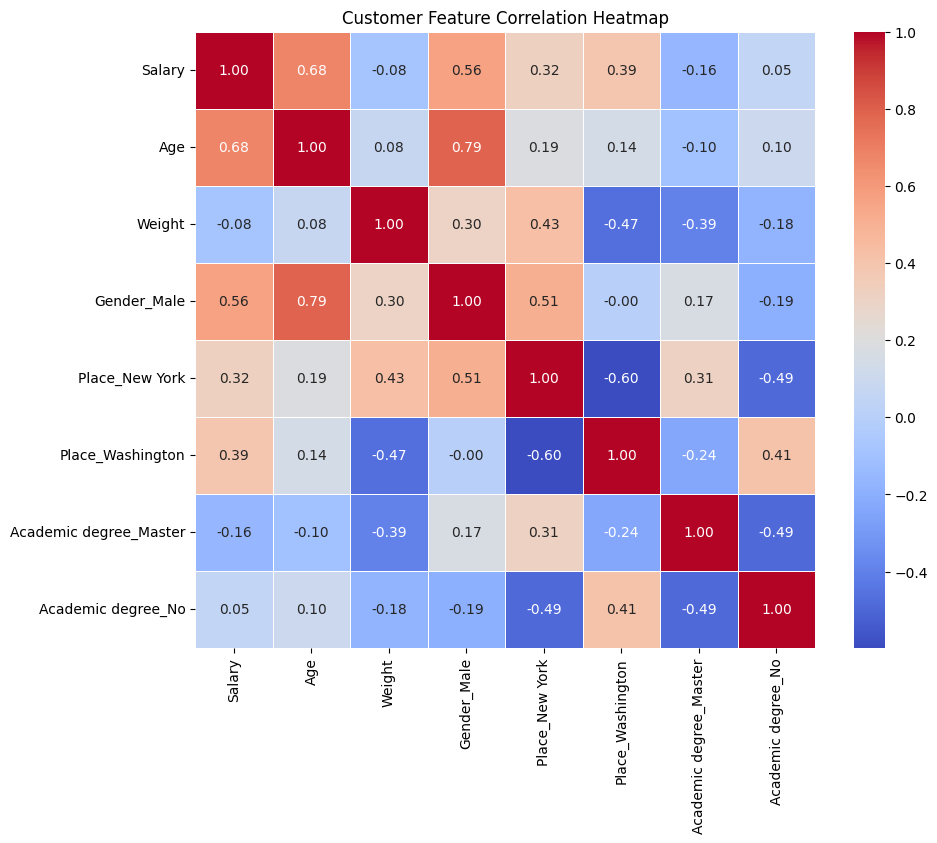

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
plt.figure(figsize=(10, 8))
correlation_matrix = X_encoded.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Customer Feature Correlation Heatmap')
plt.show()